In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()

groq_api_key = os.getenv("GROQ_API_KEY")
llm_model = ChatGroq(
temperature= 0.4,
model="llama-3.1-8b-instant",
api_key=groq_api_key
)

In [3]:
#create a typed dict for the state
class BatsmanState(TypedDict):
    #name: str
    #age: int
    #average: float
    runs: int
    balls: int
    fours: int
    sixs: int
    strike_rate: float
    bpb_rate: float
    boundary_rate: float
    summary: str

In [4]:
def calculate_strike_rate(state: BatsmanState) -> BatsmanState: 
    strike_rate = (state ["runs"] / state ["balls"]) * 100
    return {"strike_rate": strike_rate}

def calculate_bpb_rate(state: BatsmanState) -> BatsmanState:
    bpb_rate = state["balls"] / (state ["fours"] + state["sixs"])
    return {"bpb_rate": bpb_rate}

def calculate_boundary_rate(state: BatsmanState) -> BatsmanState:
    boundary_rate = (((state["fours"]*4) + (state["sixs"]*6)) / state ["runs"])*100
    return {"boundary_rate": boundary_rate}

def summary(state: BatsmanState) -> BatsmanState: 
    summary=f"Strike Rate: {state['strike_rate']:.2f} Balls per Boundary: {state['bpb_rate']:.2f} Boundary Rate: {state['boundary_rate']:.2f}"
    return {"summary": summary}

In [5]:
#create a graph
graph = StateGraph(BatsmanState)

#add nodes to the graph
graph.add_node("calculate_strike_rate", calculate_strike_rate)
graph.add_node("calculate_bpb_rate", calculate_bpb_rate)
graph.add_node("calculate_boundary_rate", calculate_boundary_rate)
graph.add_node("summary", summary)

#add edges to the graph
graph.add_edge(START, "calculate_strike_rate")
graph.add_edge(START, "calculate_bpb_rate")
graph.add_edge(START, "calculate_boundary_rate")
graph.add_edge("calculate_strike_rate", "summary")
graph.add_edge("calculate_bpb_rate", "summary")
graph.add_edge("calculate_boundary_rate", "summary")
graph.add_edge("summary", END)

# compile the graph
workflow = graph.compile()

In [6]:
# execute the graph
initial_state = {"runs": 100, "balls": 50, "fours": 6, "sixs": 4}
final_state = workflow.invoke(initial_state)
final_state

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixs': 4,
 'strike_rate': 200.0,
 'bpb_rate': 5.0,
 'boundary_rate': 48.0,
 'summary': 'Strike Rate: 200.00 Balls per Boundary: 5.00 Boundary Rate: 48.00'}

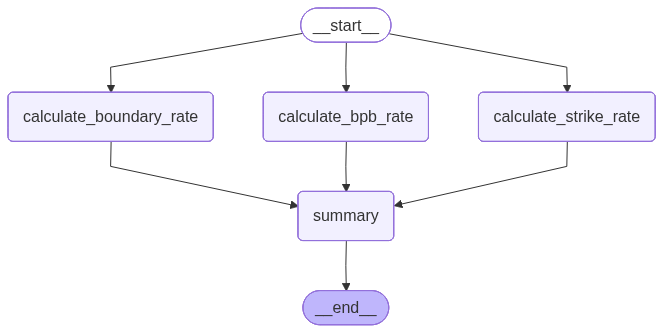

In [7]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())